# Lecture 1: Probability, Statistics, and Distributional Thinking with Python

**Probability, Statistics, and Econometrics for Finance, Accounting, and Economics**  
Campbell University, Lundy-Fetterman School of Business  

**Instructor:** Matthew L. Kelly, PhD  
**Topic:** Basic concepts of probability and statistics  
**Notebook goal:** Use Python to simulate random variables, describe distributions, and connect descriptive statistics to probability theory.

---

## Why begin here?

Econometrics begins with a simple problem: we observe data, but we do not directly observe the process that generated the data. Probability gives us a language for describing the data-generating process. Statistics gives us tools for learning about that process from samples. Econometrics applies those tools to economic and financial questions.

This first lecture builds the foundation for the rest of the course.

## How this lecture fits into a 7-lecture series

1. **Lecture 1: Probability, statistics, and distributional thinking**
   - Random variables, samples, distributions, moments, likelihood, entropy, LLN, and CLT.

2. **Lecture 2: Sampling, estimation, and hypothesis testing**
   - Estimators, sampling distributions, confidence intervals, p-values, Type I and Type II errors.

3. **Lecture 3: Simple linear regression**
   - Conditional expectation, OLS, interpretation of coefficients, residuals, fitted values.

4. **Lecture 4: Multiple regression and omitted variable bias**
   - Controls, partial effects, multicollinearity, model specification.

5. **Lecture 5: Causal inference and research design**
   - Experiments, natural experiments, difference-in-differences, instruments, regression discontinuity.

6. **Lecture 6: Time-series econometrics**
   - Autocorrelation, stationarity, trends, random walks, AR models, forecasting.

7. **Lecture 7: Financial and economic applications**
   - Return modeling, risk, volatility, CAPM-style regressions, event studies, and empirical projects.

## Learning objectives

By the end of this lecture, you should be able to:

- Explain the difference between a random variable, a realization, a sample, and a distribution.
- Simulate common probability distributions in Python.
- Calculate and interpret mean, variance, standard deviation, skewness, and kurtosis.
- Explain why quantiles, boxplots, and the Gini coefficient describe features that moments may miss.
- Use the Law of Large Numbers and Central Limit Theorem to understand why sample averages are useful.
- Explain likelihood, log-likelihood, and entropy at an introductory level.

## 1. Setup

We begin by importing the libraries used throughout the notebook.

- `NumPy` handles numerical arrays and random number generation.
- `Pandas` organizes data in tables.
- `Matplotlib` and `Seaborn` create graphs.
- `SciPy` provides probability distributions and statistical functions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import norm, uniform, expon, bernoulli, entropy
from scipy.optimize import minimize

# Make the examples reproducible.
# Change this number or remove it to see different random samples.
rng = np.random.default_rng(seed=42)

# Use a simple default figure size.
plt.rcParams["figure.figsize"] = (9, 5)

## 2. Random variables, samples, and realizations

A **random variable** is a numerical outcome generated by some uncertain process.

Formally, a random variable is a function

$$
X:\Omega \rightarrow \mathbb{R},
$$

where $\Omega$ is the set of possible states of the world and $\mathbb{R}$ is the real number line.

When we collect data, we usually observe a sample:

$$
x_1, x_2, \ldots, x_n.
$$

Each $x_i$ is a **realization** of the random variable $X$. A distribution describes how likely different realizations are.

In economics and finance, examples include:

- a household's income,
- a firm's profit,
- a stock's daily return,
- the number of defaults in a loan portfolio,
- the time between customer arrivals,
- the number of claims filed with an insurer.

## 3. Describing a sample: moments and summary statistics

The **sample mean** is

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i.
$$

The **sample variance** is

$$
s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2.
$$

The **sample standard deviation** is

$$
s = \sqrt{s^2}.
$$

The **sample skewness** measures asymmetry:

$$
\text{Skewness} =
\frac{\frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})^3}{s^3}.
$$

The **sample kurtosis** measures tail thickness relative to the variance:

$$
\text{Kurtosis} =
\frac{\frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})^4}{s^4}.
$$

Many software packages report **excess kurtosis**, which subtracts 3 so that a normal distribution has excess kurtosis near 0.

In [5]:
def summarize_sample(x, name="sample"):
    # Return common descriptive statistics for a one-dimensional sample.
    x = np.asarray(x)
    return pd.DataFrame(
        {
            "Statistic": [
                "Observations",
                "Mean",
                "Variance",
                "Standard deviation",
                "Skewness",
                "Excess kurtosis",
                "Minimum",
                "25th percentile",
                "Median",
                "75th percentile",
                "Maximum",
            ],
            name: [
                len(x),
                np.mean(x),
                np.var(x, ddof=1),
                np.std(x, ddof=1),
                stats.skew(x),
                stats.kurtosis(x),
                np.min(x),
                np.quantile(x, 0.25),
                np.median(x),
                np.quantile(x, 0.75),
                np.max(x),
            ],
        }
    )


def plot_distribution_and_path(x, title):
    # Show a histogram, a sequence plot, and a cumulative-deviation plot.
    x = np.asarray(x)

    plt.figure()
    sns.histplot(x, kde=True)
    plt.title(f"{title}: Histogram")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.show()

    plt.figure()
    plt.plot(x)
    plt.title(f"{title}: Values in the order drawn")
    plt.xlabel("Draw number")
    plt.ylabel("Value")
    plt.show()

    plt.figure()
    plt.plot((x - np.mean(x)).cumsum())
    plt.axhline(0, linestyle="--")
    plt.title(f"{title}: Cumulative deviation from sample mean")
    plt.xlabel("Draw number")
    plt.ylabel(r"$\sum_{i=1}^{t}(x_i-\bar{x})$")
    plt.show()

## 4. The normal distribution

The **normal distribution** is symmetric and is characterized by two parameters: a mean $\mu$ and standard deviation $\sigma$.

We write

$$
X \sim \mathcal{N}(\mu,\sigma^2).
$$

Its density is

$$
f(x)=
\frac{1}{\sigma\sqrt{2\pi}}
\exp\left[-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2\right].
$$

The standard normal distribution has $\mu=0$ and $\sigma=1$.

In [7]:
normal_data = rng.normal(loc=0, scale=1, size=500)

summarize_sample(normal_data, "Normal sample")

,Statistic,Normal sample
0,Observations,500.000000
1,Mean,-0.013126
2,Variance,0.921474
3,Standard deviation,0.959934
4,Skewness,0.093409
5,Excess kurtosis,-0.051650
6,Minimum,-2.566658
7,25th percentile,-0.666917
8,Median,0.003212
9,75th percentile,0.587393


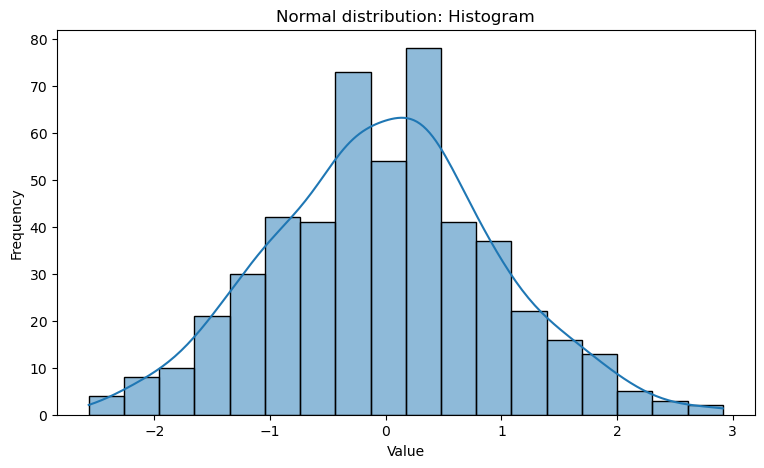

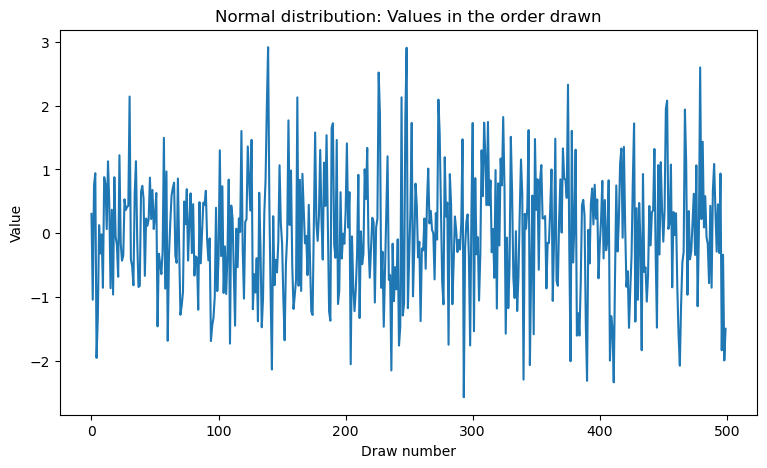

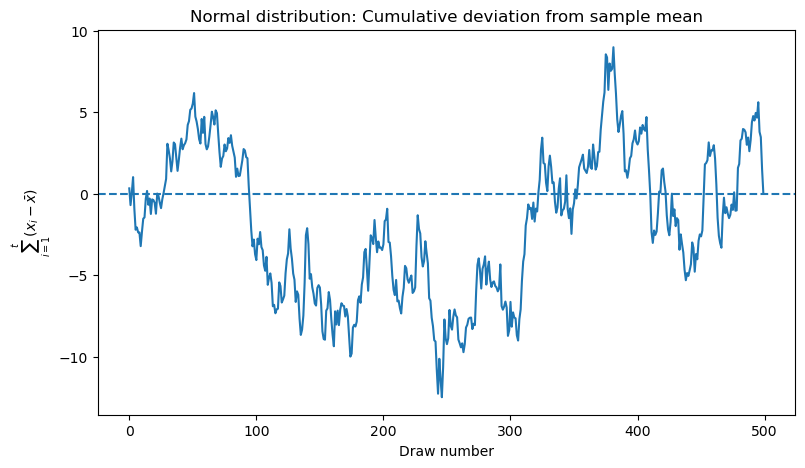

In [9]:
plot_distribution_and_path(normal_data, "Normal distribution")

## 5. Other common distributions

Different distributions are useful for different economic and financial problems.

| Distribution | Typical use | Key idea |
|---|---|---|
| Uniform | Random draw with equal probability over an interval | Every value in $[a,b]$ is equally likely |
| Exponential | Waiting times | Time between events in a Poisson process |
| Binomial | Count of successes | Number of successes in $n$ trials |
| Poisson | Count of events | Number of events in a fixed interval |
| Gamma | Waiting times and positive continuous outcomes | Flexible right-skewed distribution |
| Log-normal | Asset prices, incomes, sizes | Logarithm is normally distributed |

In [11]:
samples = {
    "Uniform [-10, 10]": rng.uniform(low=-10, high=10, size=1000),
    "Exponential, scale=1": rng.exponential(scale=1, size=1000),
    "Binomial, n=10, p=0.5": rng.binomial(n=10, p=0.5, size=1000),
    "Poisson, lambda=3": rng.poisson(lam=3, size=1000),
    "Gamma, shape=2, scale=2": rng.gamma(shape=2, scale=2, size=1000),
    "Log-normal, mu=0, sigma=1": rng.lognormal(mean=0, sigma=1, size=1000),
}

summary_tables = []

for name, values in samples.items():
    table = summarize_sample(values, name).set_index("Statistic")
    summary_tables.append(table)

distribution_summary = pd.concat(summary_tables, axis=1)
distribution_summary.round(3)

,"Uniform [-10, 10]","Exponential, scale=1","Binomial, n=10, p=0.5","Poisson, lambda=3","Gamma, shape=2, scale=2","Log-normal, mu=0, sigma=1"
Statistic,,,,,,
Observations,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
Mean,0.029,1.018,4.965,2.932,3.877,1.649
Variance,34.430,1.150,2.568,2.904,7.314,5.128
Standard deviation,5.868,1.073,1.603,1.704,2.704,2.264
Skewness,0.028,2.364,-0.041,0.484,1.285,4.318
Excess kurtosis,-1.213,8.581,-0.125,0.009,2.422,25.169
Minimum,-9.990,0.001,0.000,0.000,0.090,0.046
25th percentile,-5.134,0.289,4.000,2.000,1.858,0.498
Median,-0.181,0.691,5.000,3.000,3.248,0.946


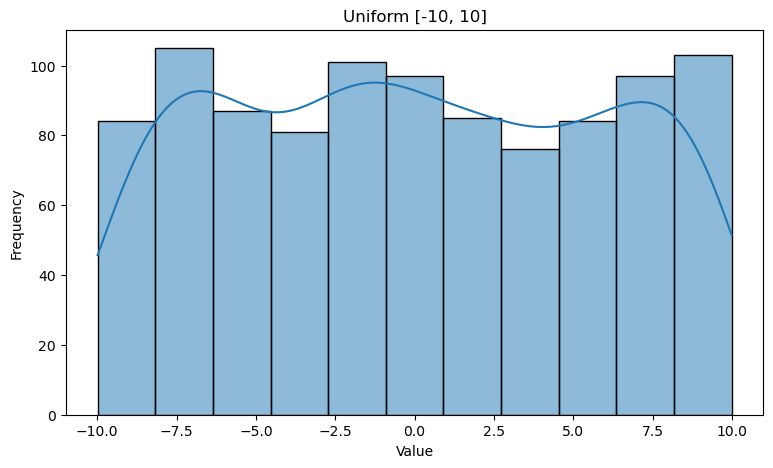

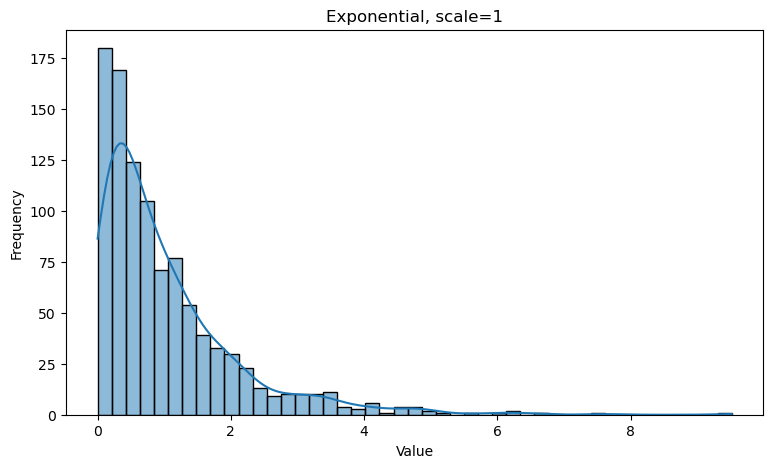

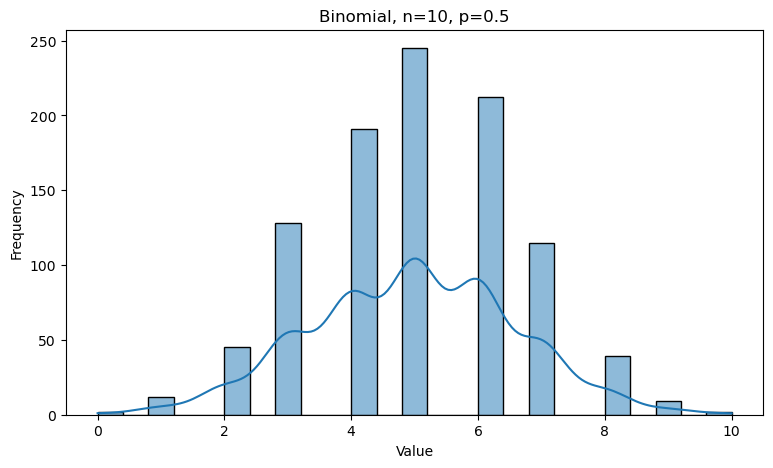

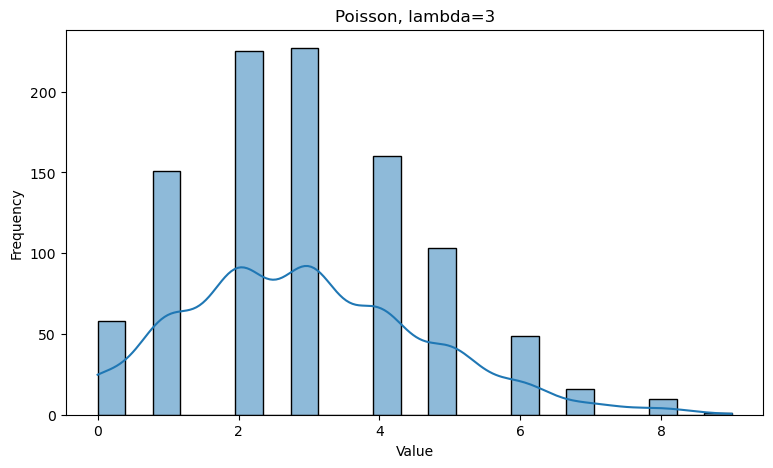

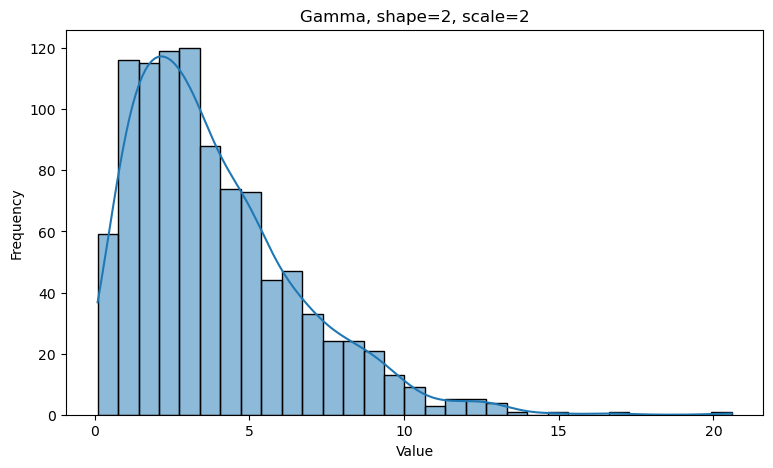

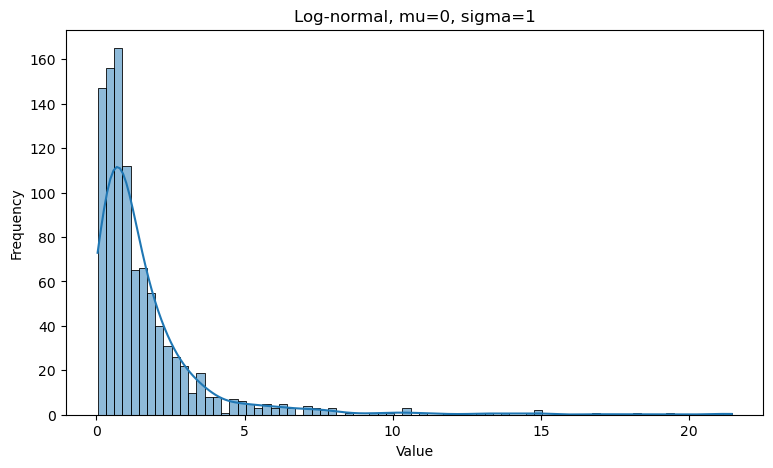

In [13]:
for name, values in samples.items():
    plt.figure()
    sns.histplot(values, kde=True)
    plt.title(name)
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.show()

## 6. A distribution is not the same thing as a time series

The samples above are independent random draws. We can plot them in the order drawn, but the order does not necessarily represent time.

A useful diagnostic is the cumulative deviation from the sample mean:

$$
S_t = \sum_{i=1}^{t}(x_i-\bar{x}).
$$

If observations are independent and have a stable mean, the centered cumulative sum may wander, but it should not drift permanently in one direction. This idea anticipates later topics such as stationarity and time-series modeling.

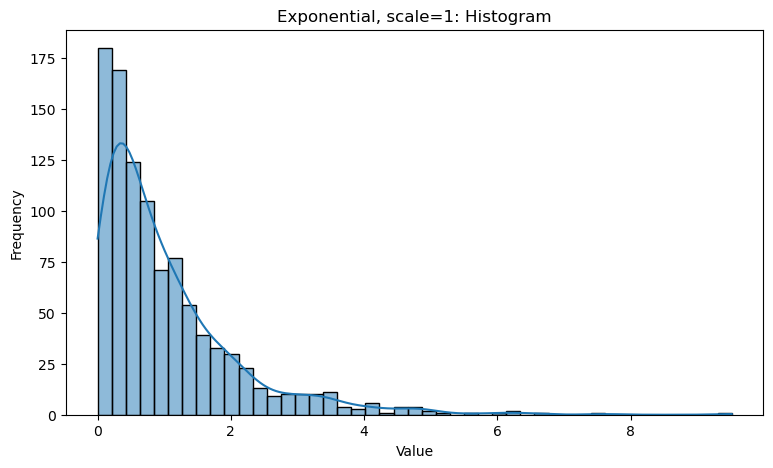

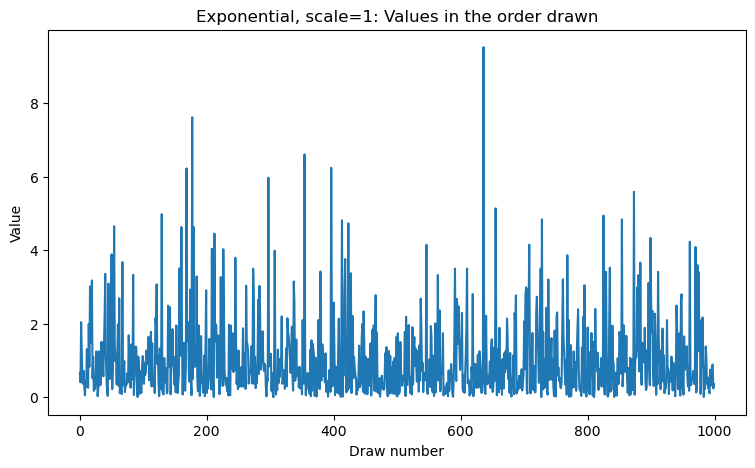

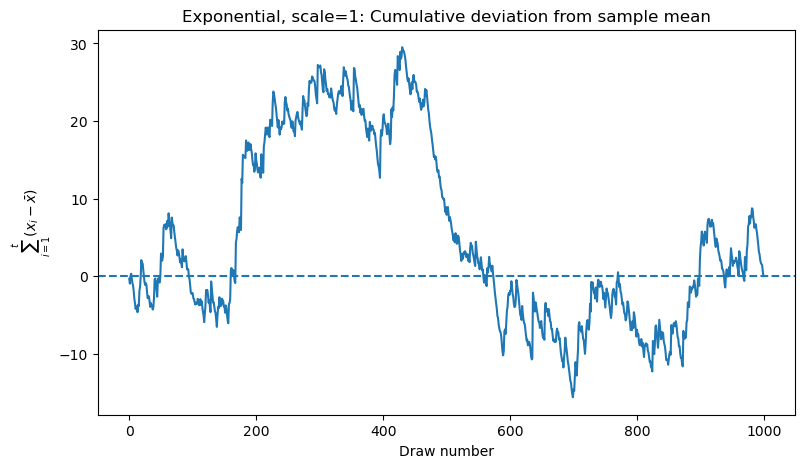

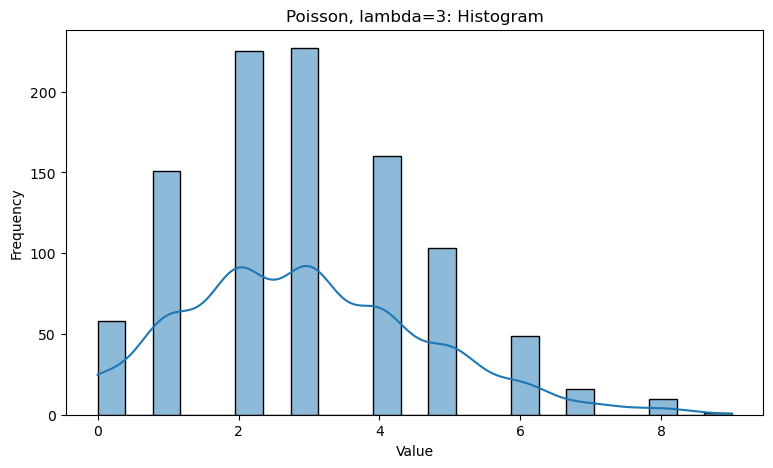

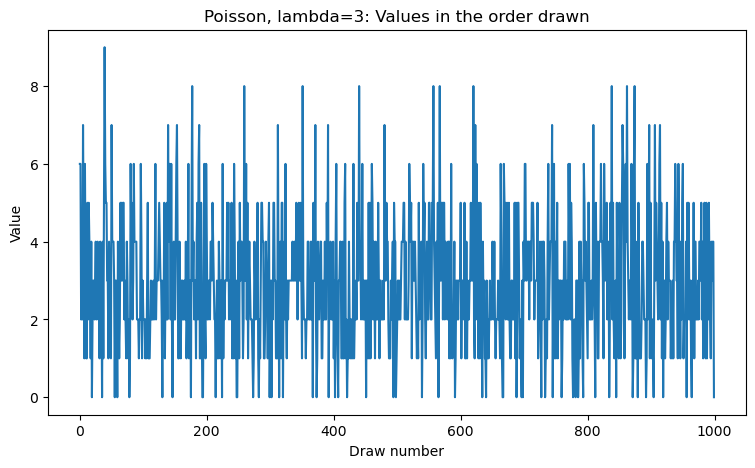

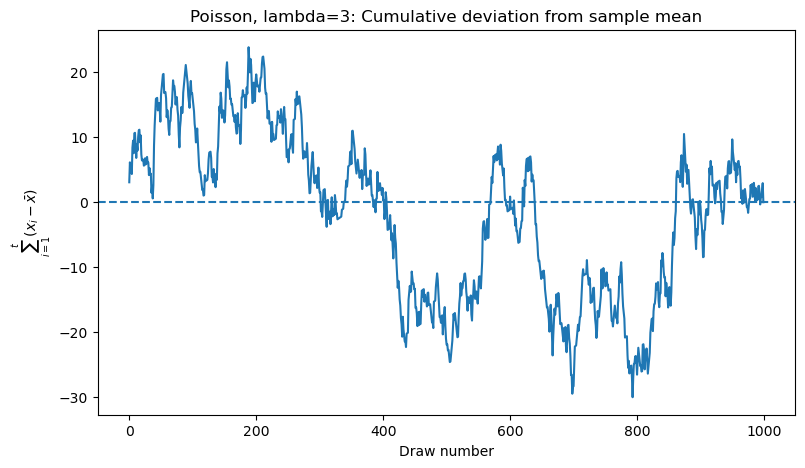

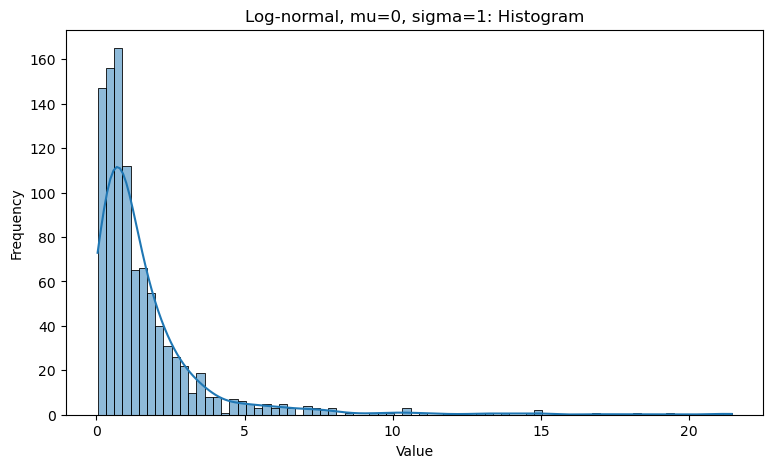

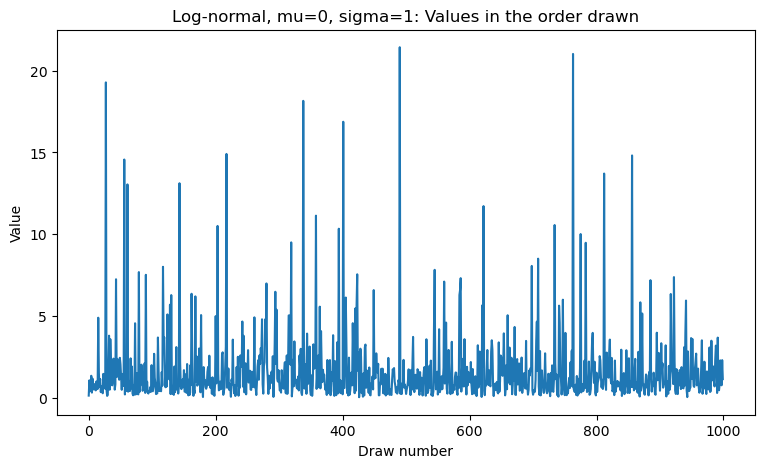

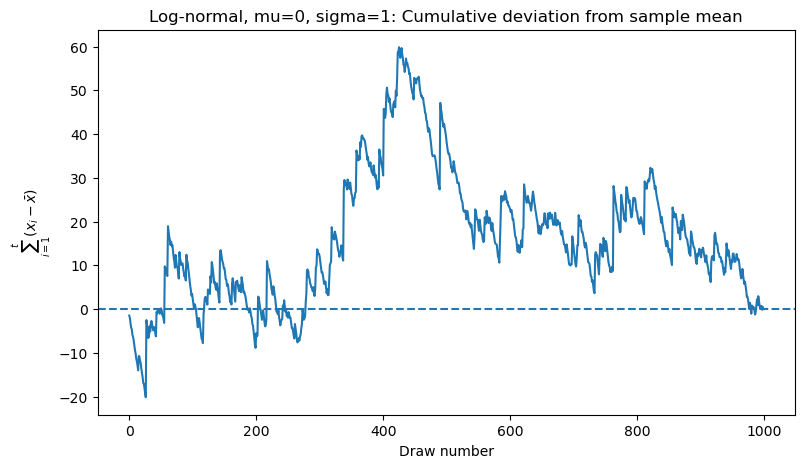

In [15]:
for name in ["Exponential, scale=1", "Poisson, lambda=3", "Log-normal, mu=0, sigma=1"]:
    plot_distribution_and_path(samples[name], name)

## 7. Types of data and a small classroom example

Data can be **numerical** or **categorical**.

Numerical data can be:

- **Discrete:** counts, such as number of students or number of defaults.
- **Continuous:** measurements, such as height, income, prices, or returns.

Categorical data can be:

- **Nominal:** unordered categories, such as industry or color.
- **Ordinal:** ordered categories, such as ratings or class rank.

Here is a small classroom-style dataset.

In [17]:
class_data = pd.DataFrame(
    {
        "Age": [22, 25, 30, 22, 29, 24, 25, 30, 22, 27],
        "Height": [5.5, 5.7, 5.8, 5.5, 6.0, 5.6, 5.7, 5.8, 5.5, 5.9],
        "Score": [85, 90, 88, 85, 91, 87, 89, 88, 85, 90],
    }
)

class_data

,Age,Height,Score
0,22,5.5,85
1,25,5.7,90
2,30,5.8,88
3,22,5.5,85
4,29,6.0,91
5,24,5.6,87
6,25,5.7,89
7,30,5.8,88
8,22,5.5,85
9,27,5.9,90


In [19]:
class_summary = class_data.agg(["mean", "median", "std", "min", "max"])
class_summary

,Age,Height,Score
mean,25.600000,5.700000,87.800000
median,25.000000,5.700000,88.000000
std,3.238655,0.176383,2.250926
min,22.000000,5.500000,85.000000
max,30.000000,6.000000,91.000000


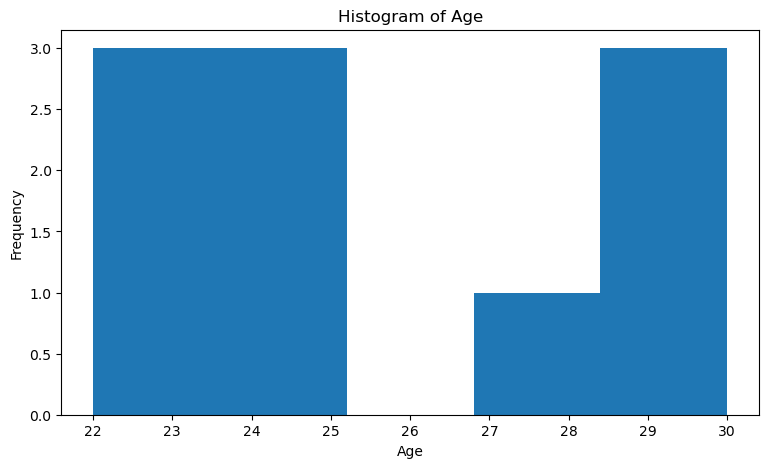

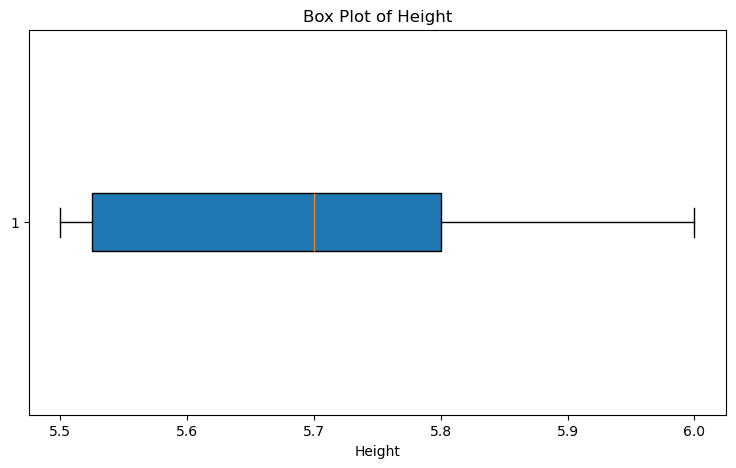

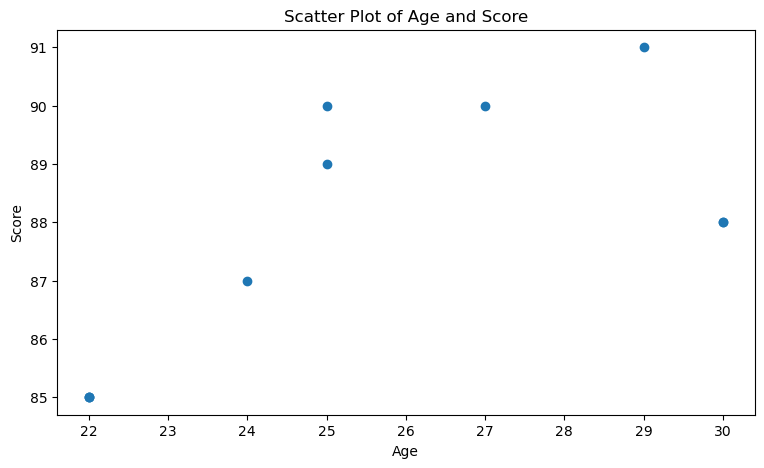

In [21]:
plt.figure()
plt.hist(class_data["Age"], bins=5)
plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.boxplot(class_data["Height"], vert=False, patch_artist=True)
plt.title("Box Plot of Height")
plt.xlabel("Height")
plt.show()

plt.figure()
plt.scatter(class_data["Age"], class_data["Score"])
plt.title("Scatter Plot of Age and Score")
plt.xlabel("Age")
plt.ylabel("Score")
plt.show()

## 8. Quantiles, boxplots, and the Gini coefficient

Moments are useful, but they do not tell us everything. Quantiles describe points in the distribution.

The $p$-th quantile $q_p$ is the value such that

$$
P(X \le q_p)=p.
$$

Common examples:

- $q_{0.25}$: first quartile,
- $q_{0.50}$: median,
- $q_{0.75}$: third quartile.

Another descriptor is the **Gini coefficient**, often used to measure inequality. If all observations are nonnegative, a common sample formula is

$$
G =
\frac{\sum_{i=1}^{n}(2i-n-1)x_{(i)}}{n\sum_{i=1}^{n}x_i},
$$

where $x_{(i)}$ is the $i$-th ordered observation.

In [23]:
def gini_coefficient(x):
    # Compute the Gini coefficient for nonnegative observations.
    x = np.asarray(x)

    if np.any(x < 0):
        raise ValueError("The Gini coefficient in this formula requires nonnegative observations.")

    sorted_x = np.sort(x)
    n = len(sorted_x)
    index = np.arange(1, n + 1)

    return np.sum((2 * index - n - 1) * sorted_x) / (n * np.sum(sorted_x))


income_like_data = rng.lognormal(mean=10, sigma=0.7, size=1000)

quantiles = np.quantile(income_like_data, [0.25, 0.50, 0.75])
gini = gini_coefficient(income_like_data)

print(f"25th percentile: {quantiles[0]:,.2f}")
print(f"50th percentile: {quantiles[1]:,.2f}")
print(f"75th percentile: {quantiles[2]:,.2f}")
print(f"Gini coefficient: {gini:.3f}")

25th percentile: 13,718.96
50th percentile: 21,911.11
75th percentile: 35,558.21
Gini coefficient: 0.388


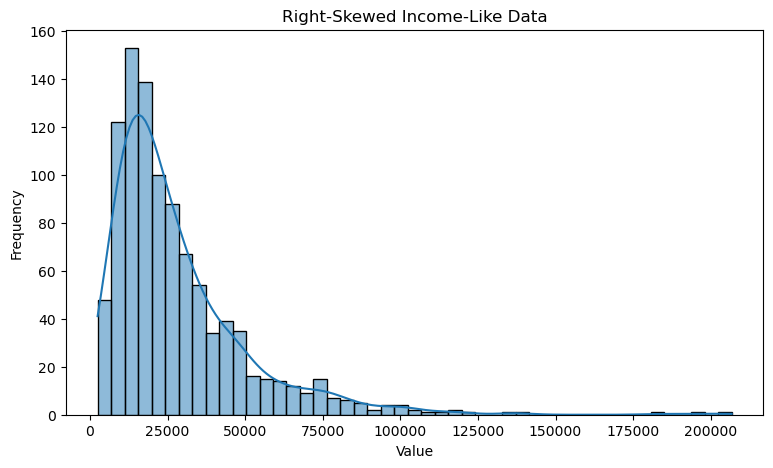

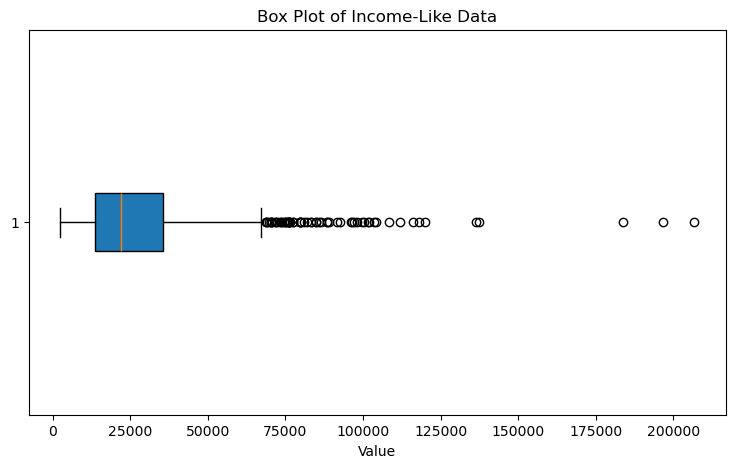

In [25]:
plt.figure()
sns.histplot(income_like_data, kde=True)
plt.title("Right-Skewed Income-Like Data")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.boxplot(income_like_data, vert=False, patch_artist=True)
plt.title("Box Plot of Income-Like Data")
plt.xlabel("Value")
plt.show()

## 9. PDF, PMF, and CDF

For a **continuous** random variable, the **probability density function** or PDF describes relative density:

$$
P(a \le X \le b)=\int_a^b f(x)\,dx.
$$

For a **discrete** random variable, the **probability mass function** or PMF gives probabilities directly:

$$
P(X=x)=p(x).
$$

The **cumulative distribution function** or CDF is

$$
F(x)=P(X\le x).
$$

For a continuous random variable,

$$
F(x)=\int_{-\infty}^{x} f(t)\,dt.
$$


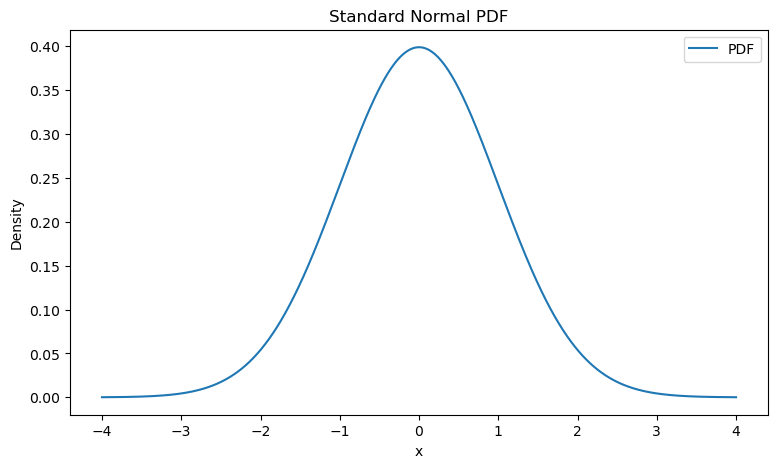

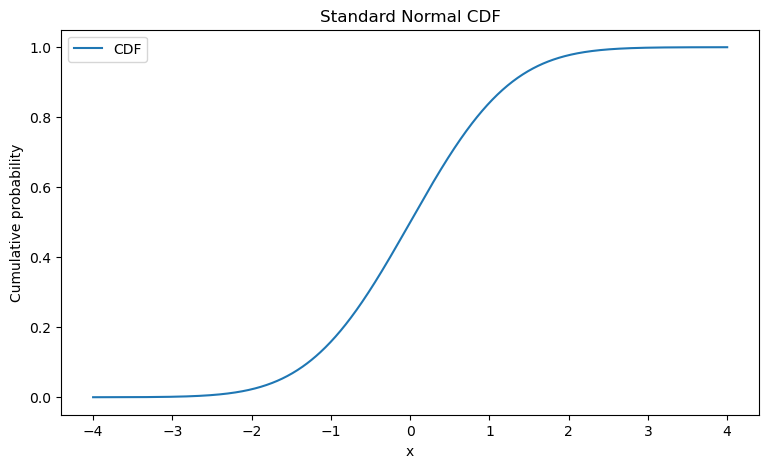

In [27]:
x = np.linspace(-4, 4, 1000)

plt.figure()
plt.plot(x, norm.pdf(x, loc=0, scale=1), label="PDF")
plt.title("Standard Normal PDF")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()

plt.figure()
plt.plot(x, norm.cdf(x, loc=0, scale=1), label="CDF")
plt.title("Standard Normal CDF")
plt.xlabel("x")
plt.ylabel("Cumulative probability")
plt.legend()
plt.show()

## 10. Convergence and the Law of Large Numbers

The **Law of Large Numbers** says that the sample mean converges to the expected value as the sample size grows.

If $X_1, X_2, \ldots, X_n$ are independent and identically distributed with finite expected value $E[X_i]=\mu$, then

$$
\bar{X}_n =
\frac{1}{n}\sum_{i=1}^{n}X_i
\rightarrow \mu
$$

as $n$ becomes large.

This is why sample averages are useful: the average of many observations can be more stable than any single observation.

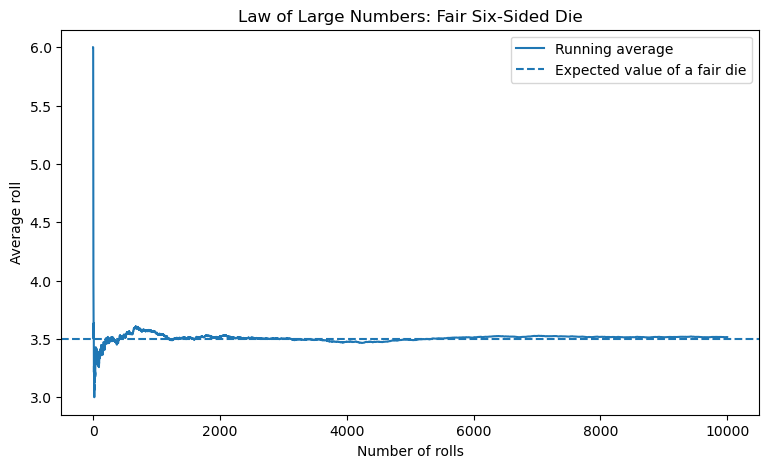

In [29]:
# Demonstrate the Law of Large Numbers with die rolls.
num_rolls = 10_000
die_rolls = rng.integers(low=1, high=7, size=num_rolls)
running_average = np.cumsum(die_rolls) / np.arange(1, num_rolls + 1)

plt.figure()
plt.plot(running_average, label="Running average")
plt.axhline(3.5, linestyle="--", label="Expected value of a fair die")
plt.title("Law of Large Numbers: Fair Six-Sided Die")
plt.xlabel("Number of rolls")
plt.ylabel("Average roll")
plt.legend()
plt.show()

## 11. The Central Limit Theorem

The **Central Limit Theorem** says that averages of many independent observations tend to be approximately normally distributed, even when the original data are not normal.

For independent and identically distributed observations with mean $\mu$ and variance $\sigma^2$,

$$
\frac{\bar{X}_n-\mu}{\sigma/\sqrt{n}}
\Rightarrow \mathcal{N}(0,1)
$$

as $n$ becomes large.

The symbol $\Rightarrow$ denotes convergence in distribution.

This theorem is one reason normal approximations appear throughout statistics, economics, and finance.

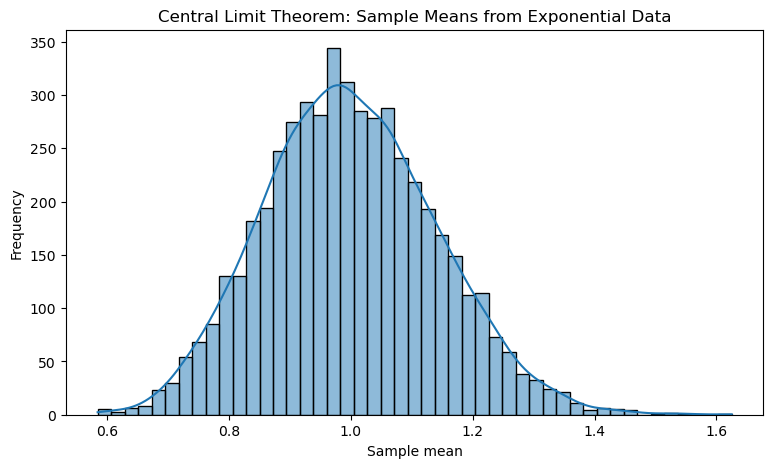

Mean of sample means: 1.000
Standard deviation of sample means: 0.141
Theoretical standard error: 0.141


In [31]:
# Demonstrate the CLT using an exponential distribution, which is strongly right-skewed.
sample_size = 50
num_samples = 5000

sample_means = np.array(
    [np.mean(rng.exponential(scale=1, size=sample_size)) for _ in range(num_samples)]
)

plt.figure()
sns.histplot(sample_means, kde=True)
plt.title("Central Limit Theorem: Sample Means from Exponential Data")
plt.xlabel("Sample mean")
plt.ylabel("Frequency")
plt.show()

print(f"Mean of sample means: {sample_means.mean():.3f}")
print(f"Standard deviation of sample means: {sample_means.std(ddof=1):.3f}")
print(f"Theoretical standard error: {1 / np.sqrt(sample_size):.3f}")

## 12. Likelihood and log-likelihood

Suppose we observe data $x_1,\ldots,x_n$ and assume that the data come from a distribution with parameter vector $\theta$.

The **likelihood function** is

$$
L(\theta \mid x_1,\ldots,x_n)
=
\prod_{i=1}^{n} f(x_i \mid \theta).
$$

The **log-likelihood** is

$$
\ell(\theta \mid x_1,\ldots,x_n)
=
\log L(\theta \mid x_1,\ldots,x_n)
=
\sum_{i=1}^{n}\log f(x_i \mid \theta).
$$

Log-likelihoods are easier to work with because products become sums. Maximum likelihood estimation chooses the parameter value that makes the observed data most likely under the model.

For a normal model with mean $\mu$ and standard deviation $\sigma$,

$$
\ell(\mu,\sigma)
=
\sum_{i=1}^{n}
\log
\left[
\frac{1}{\sigma\sqrt{2\pi}}
\exp\left(
-\frac{1}{2}\left(\frac{x_i-\mu}{\sigma}\right)^2
\right)
\right].
$$


In [33]:
# Generate data from a normal distribution with known parameters.
mle_data = rng.normal(loc=5, scale=2, size=100)

def normal_log_likelihood(data, mu, sigma):
    # Log-likelihood of normal data given mu and sigma.
    if sigma <= 0:
        return -np.inf
    return np.sum(norm.logpdf(data, loc=mu, scale=sigma))

mu_values = np.linspace(3.5, 6.5, 100)
sigma_values = np.linspace(0.5, 3.5, 100)

log_likelihoods = np.zeros((len(mu_values), len(sigma_values)))

for i, mu in enumerate(mu_values):
    for j, sigma in enumerate(sigma_values):
        log_likelihoods[i, j] = normal_log_likelihood(mle_data, mu, sigma)

max_index = np.unravel_index(np.argmax(log_likelihoods), log_likelihoods.shape)
max_mu = mu_values[max_index[0]]
max_sigma = sigma_values[max_index[1]]
max_log_likelihood = log_likelihoods[max_index]

print(f"Maximum log-likelihood on grid: {max_log_likelihood:.2f}")
print(f"Grid estimate of mu: {max_mu:.2f}")
print(f"Grid estimate of sigma: {max_sigma:.2f}")

Maximum log-likelihood on grid: -208.73
Grid estimate of mu: 4.89
Grid estimate of sigma: 1.95


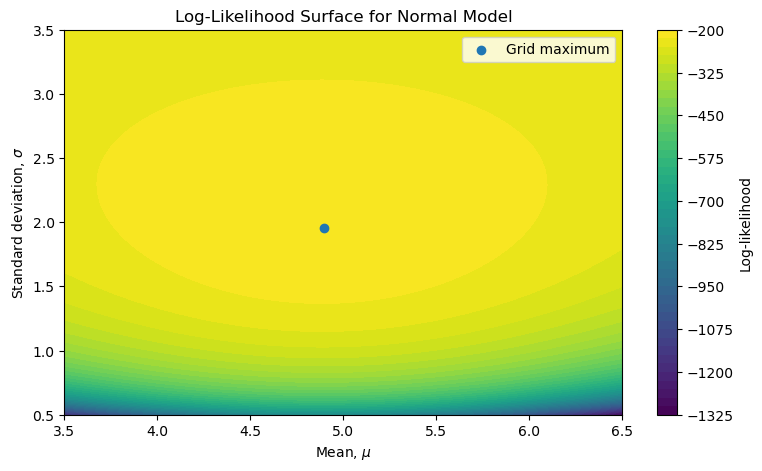

In [35]:
plt.figure()
plt.contourf(mu_values, sigma_values, log_likelihoods.T, levels=50)
plt.colorbar(label="Log-likelihood")
plt.scatter(max_mu, max_sigma, label="Grid maximum")
plt.title("Log-Likelihood Surface for Normal Model")
plt.xlabel(r"Mean, $\mu$")
plt.ylabel(r"Standard deviation, $\sigma$")
plt.legend()
plt.show()

In [37]:
def negative_normal_log_likelihood(params, data):
    # Negative log-likelihood for numerical minimization.
    mu, sigma = params
    return -normal_log_likelihood(data, mu, sigma)

result = minimize(
    negative_normal_log_likelihood,
    x0=np.array([4.0, 1.0]),
    args=(mle_data,),
    bounds=[(None, None), (1e-8, None)],
)

optimal_mu, optimal_sigma = result.x

print(f"MLE estimate of mu: {optimal_mu:.3f}")
print(f"MLE estimate of sigma: {optimal_sigma:.3f}")
print(f"Sample mean: {mle_data.mean():.3f}")
print(f"Sample standard deviation: {mle_data.std(ddof=0):.3f}")

MLE estimate of mu: 4.885
MLE estimate of sigma: 1.951
Sample mean: 4.885
Sample standard deviation: 1.951


## 13. Entropy as uncertainty

Entropy measures uncertainty in a probability distribution.

For a discrete random variable $X$ with outcomes $x_1,\ldots,x_n$ and probabilities $p_1,\ldots,p_n$, entropy is

$$
H(X)
=
-\sum_{i=1}^{n}p_i\log(p_i).
$$

For a continuous random variable with density $f(x)$, differential entropy is

$$
H(X)
=
-\int_{-\infty}^{\infty} f(x)\log f(x)\,dx.
$$

A fair coin has more entropy than a heavily biased coin because the fair coin is harder to predict.

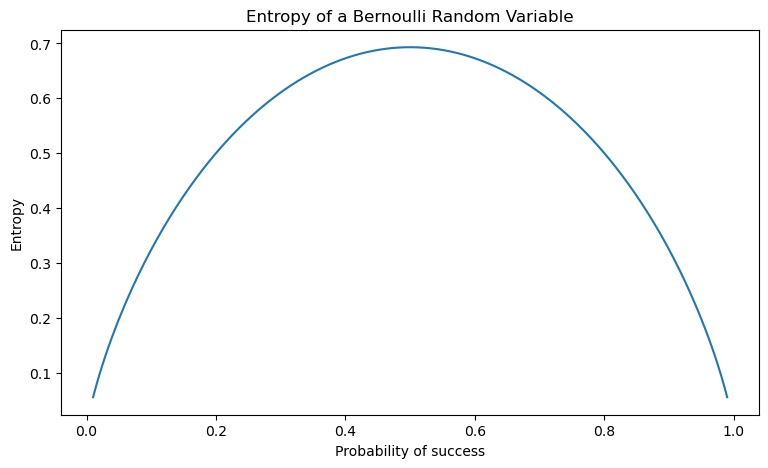

Entropy when p = 0.50: 0.693
Entropy when p = 0.95: 0.199


In [39]:
p_values = np.linspace(0.01, 0.99, 200)
bernoulli_entropy = np.array([bernoulli.entropy(p) for p in p_values])

plt.figure()
plt.plot(p_values, bernoulli_entropy)
plt.title("Entropy of a Bernoulli Random Variable")
plt.xlabel("Probability of success")
plt.ylabel("Entropy")
plt.show()

print(f"Entropy when p = 0.50: {bernoulli.entropy(0.50):.3f}")
print(f"Entropy when p = 0.95: {bernoulli.entropy(0.95):.3f}")

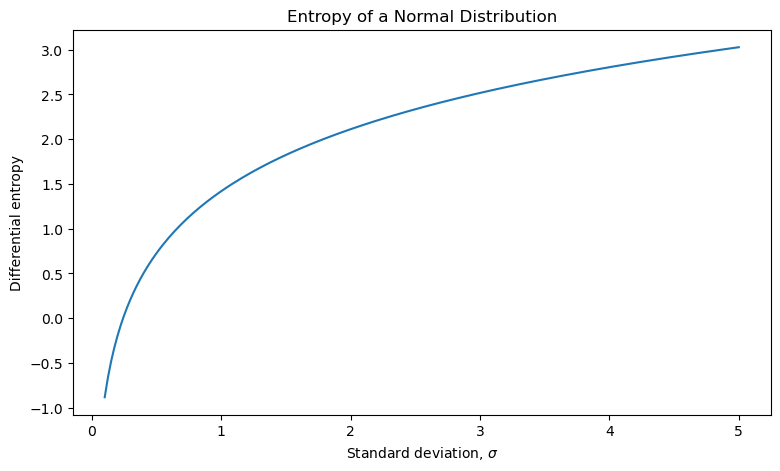

In [41]:
sigma_values = np.linspace(0.1, 5, 200)
normal_entropy = np.array([norm.entropy(loc=0, scale=sigma) for sigma in sigma_values])

plt.figure()
plt.plot(sigma_values, normal_entropy)
plt.title("Entropy of a Normal Distribution")
plt.xlabel(r"Standard deviation, $\sigma$")
plt.ylabel("Differential entropy")
plt.show()

## 14. Bringing the lecture together

This lecture introduced the vocabulary and computational tools needed for probability, statistics, and econometrics.

The main ideas are:

1. Data are observations generated by some process.
2. Probability distributions describe possible outcomes before the data are observed.
3. Summary statistics describe observed data after the data are observed.
4. Moments, quantiles, and inequality measures summarize different features of a distribution.
5. The Law of Large Numbers explains why averages stabilize.
6. The Central Limit Theorem explains why normal approximations are so common.
7. Likelihood connects probability models to parameter estimation.
8. Entropy gives a formal way to discuss uncertainty.

In the next lecture, we will use these ideas to study sampling distributions, estimation, confidence intervals, and hypothesis testing.

## Practice problems

1. **Distribution simulation**  
   Generate 1,000 observations from a log-normal distribution. Calculate the mean, variance, skewness, and excess kurtosis. Compare those statistics to a normal sample of the same size.

2. **Law of Large Numbers**  
   Simulate 10,000 rolls of a fair six-sided die. Plot the running average. Does it converge toward 3.5?

3. **Central Limit Theorem**  
   Draw repeated samples from a uniform distribution and plot the distribution of sample means. Repeat this for sample sizes $n=5$, $n=30$, and $n=100$.

4. **Likelihood**  
   Generate data from a normal distribution with $\mu=10$ and $\sigma=3$. Estimate $\mu$ and $\sigma$ using maximum likelihood.

5. **Entropy**  
   Calculate the entropy of a Bernoulli random variable for $p=0.1$, $p=0.5$, and $p=0.9$. Explain why the entropy is highest at $p=0.5$.